In [24]:
from sqlalchemy import create_engine
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import numpy as np

In [25]:
def sql_query_staging_db(query: str) -> pd.DataFrame:
    conn = psycopg2.connect(
        host="localhost",  # Use container name here
        database="staging-db",
        user="root",
        password="1234"
    )
    try:
        df = pd.read_sql(query, con=conn)
    except Exception as e:
        conn.close()
        raise e
    conn.close()
    return df

In [26]:
query = """
    SELECT * FROM medicamentos;
"""

In [27]:
df = sql_query_staging_db(query)

C:\Users\Marcelo\AppData\Local\Temp\ipykernel_20432\3226864735.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=conn)


In [23]:
df

,codigo_anvisa,nome_produto,numero_registro,numero_processo,principio_ativo,categoria_regulatoria,cnpj_laboratorio,razao_social_laboratorio
0,2762872,18F-PSMA1007,NaN,25351093523202175,AMESPRO FLUORNICOTINAMIDA (18 F),Radiofármaco,8820007000161,CMR CAMPINAS PHARMA LTDA
1,765613,A SAÚDE DA MULHER,102351059.0,25351668917201032,"TINTURA AGONIADA PLUMÉRIA, SALICILATO DE SÓDIO...",Novo,57507378000365,EMS S/A
2,3548748,AAS,178170936.0,25351497156202266,ACIDO ACETILSALICILICO,Similar,61082426000207,COSMED INDUSTRIA DE COSMETICOS E MEDICAMENTOS ...
3,3529192,AAS PROTECT,178170931.0,25351497237202266,ÁCIDO ACETILSALICÍLICO,Similar,61082426000207,COSMED INDUSTRIA DE COSMETICOS E MEDICAMENTOS ...
4,428320,ABC,106890153.0,25351141033200572,CLOTRIMAZOL,Similar,92695691000103,KLEY HERTZ FARMACEUTICA S.A
...,...,...,...,...,...,...,...,...
10475,666926,ácido zoledrônico,100431026.0,25351515342200983,ácido zoledrônico monoidratado,Genérico,61190096000192,EUROFARMA LABORATÓRIOS S.A.
10476,903696,ácido zoledrônico,100410162.0,25351389723201352,ácido zoledrônico monoidratado,Genérico,49324221000104,FRESENIUS KABI BRASIL LTDA
10477,796006,ácido zoledrônico,146820032.0,25351686804201172,ácido zoledrônico monoidratado,Genérico,5035244000123,SUN FARMACÊUTICA DO BRASIL LTDA
10478,1012584,ácido zoledrônico,188300060.0,25351771065201417,ácido zoledrônico monoidratado,Genérico,11643096000122,VIATRIS FARMACEUTICA DO BRASIL LTDA


## Old

In [19]:
#principais_laboratorios = df.groupby('nome_laboratorio')['nome'].count().sort_values(ascending=False).head(10).reset_index()
#categorias_regulatorias = df.groupby('categoria_regulatoria')['nome'].count().sort_values(ascending=False).head(10).reset_index()
#principios_ativos = df.groupby('principio_ativo')['nome'].count().sort_values(ascending=False).head(10).reset_index()

In [20]:
print(f'Total de Medicamentos: {len(df)}')
#print(f'Total de Princípios Ativos Únicos: {len(df.drop_duplicates(subset="principio_ativo"))}')
#print(f'Total de Códigos Laboratórios Únicos: {len(df.drop_duplicates(subset="codigo_laboratorio"))}')
#print(f'Total de Laboratórios Únicos: {len(df.drop_duplicates(subset="nome_laboratorio"))}')

Total de Medicamentos: 10480


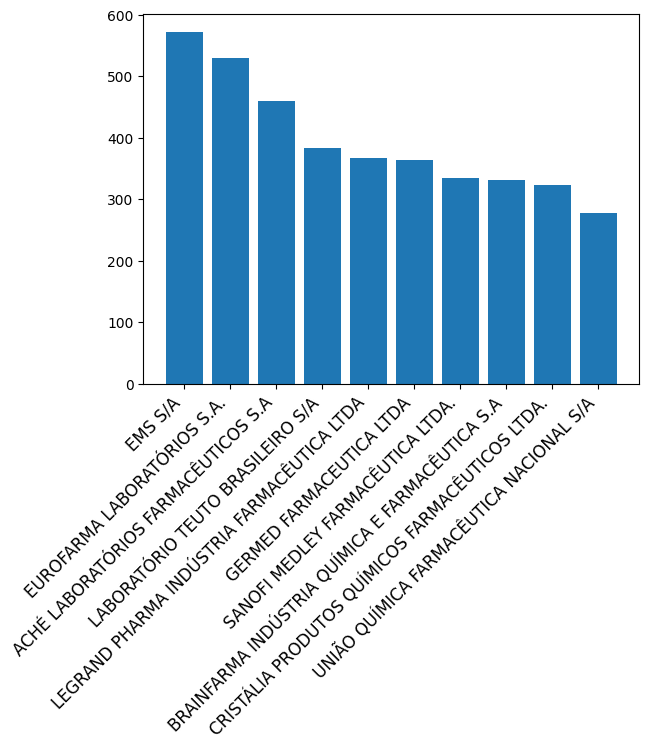

In [131]:
plt.bar(principais_laboratorios['nome_laboratorio'], principais_laboratorios['nome'])
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.show()

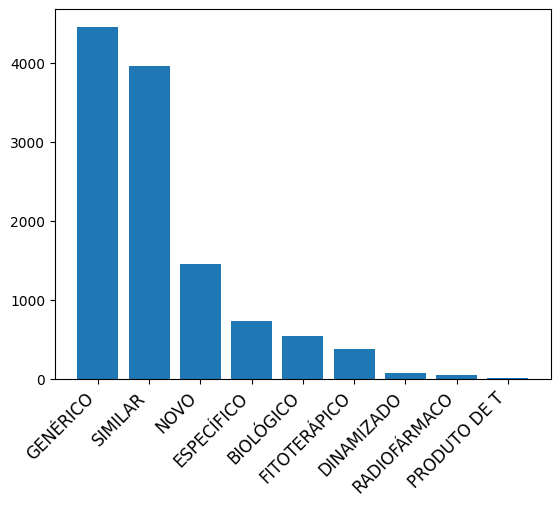

In [119]:
plt.bar(categorias_regulatorias['categoria_regulatoria'], categorias_regulatorias['nome'])
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.show()

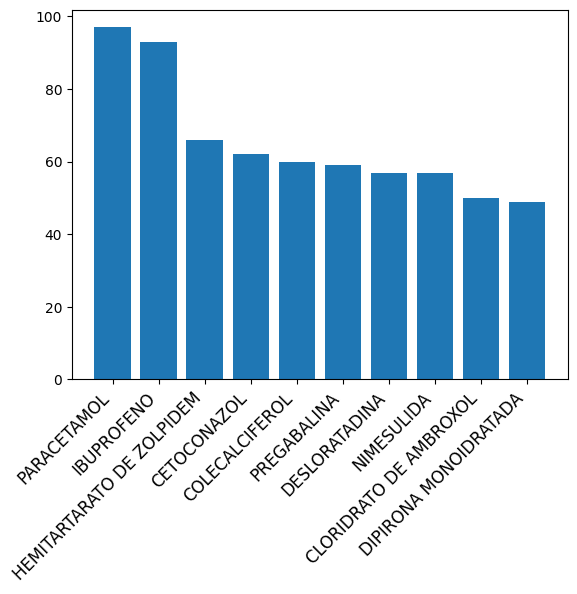

In [120]:
plt.bar(principios_ativos['principio_ativo'], principios_ativos['nome'])
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.show()

## New

In [22]:
df

,codigo_anvisa,nome_produto,numero_registro,numero_processo,principio_ativo,categoria_regulatoria,cnpj_laboratorio,razao_social_laboratorio
0,2762872,18F-PSMA1007,NaN,25351093523202175,AMESPRO FLUORNICOTINAMIDA (18 F),Radiofármaco,8820007000161,CMR CAMPINAS PHARMA LTDA
1,765613,A SAÚDE DA MULHER,102351059.0,25351668917201032,"TINTURA AGONIADA PLUMÉRIA, SALICILATO DE SÓDIO...",Novo,57507378000365,EMS S/A
2,3548748,AAS,178170936.0,25351497156202266,ACIDO ACETILSALICILICO,Similar,61082426000207,COSMED INDUSTRIA DE COSMETICOS E MEDICAMENTOS ...
3,3529192,AAS PROTECT,178170931.0,25351497237202266,ÁCIDO ACETILSALICÍLICO,Similar,61082426000207,COSMED INDUSTRIA DE COSMETICOS E MEDICAMENTOS ...
4,428320,ABC,106890153.0,25351141033200572,CLOTRIMAZOL,Similar,92695691000103,KLEY HERTZ FARMACEUTICA S.A
...,...,...,...,...,...,...,...,...
10475,666926,ácido zoledrônico,100431026.0,25351515342200983,ácido zoledrônico monoidratado,Genérico,61190096000192,EUROFARMA LABORATÓRIOS S.A.
10476,903696,ácido zoledrônico,100410162.0,25351389723201352,ácido zoledrônico monoidratado,Genérico,49324221000104,FRESENIUS KABI BRASIL LTDA
10477,796006,ácido zoledrônico,146820032.0,25351686804201172,ácido zoledrônico monoidratado,Genérico,5035244000123,SUN FARMACÊUTICA DO BRASIL LTDA
10478,1012584,ácido zoledrônico,188300060.0,25351771065201417,ácido zoledrônico monoidratado,Genérico,11643096000122,VIATRIS FARMACEUTICA DO BRASIL LTDA


In [30]:
df.to_csv("Medicamentos no Banco.csv")